In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.9 MB/s eta 0:00:00


In [32]:
from ultralytics import YOLO
import cv2
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from google.colab import files
from base64 import b64encode
import io
from PIL import Image as PILImage
import gradio as gr
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
video_path = "/content/Test.mp4"

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("Video path:", video_path)
print("Total frames:", total_frames)
print("Original video FPS:", video_fps)
print("Width:", width)
print("Height:", height)

Video path: /content/Test.mp4
Total frames: 942
Original video FPS: 30.0
Width: 1280
Height: 720


In [5]:
models = {
    "YOLOv10n": "yolov10n.pt",
    "YOLOv11n": "yolo11n.pt",
    "YOLOv12n": "yolo12n.pt"
}

In [6]:
def run_tracking(model_name, model_weight, video_path):
    print("=" * 60)
    print("Running:", model_name)
    print("=" * 60)

    model = YOLO(model_weight)

    output_path = f"/content/{model_name}_tracking.mp4"

    cap = cv2.VideoCapture(video_path)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, original_fps, (width, height))

    frame_count = 0
    total_inference_time = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        start_time = time.time()

        results = model.track(
            frame,
            persist=True,
            tracker="bytetrack.yaml",
            conf=0.25,
            verbose=False
        )

        end_time = time.time()

        inference_time = end_time - start_time
        total_inference_time += inference_time

        annotated_frame = results[0].plot()
        out.write(annotated_frame)

        frame_count += 1

    cap.release()
    out.release()

    avg_time_per_frame = total_inference_time / frame_count
    fps = frame_count / total_inference_time

    result = {
        "Model": model_name,
        "Frames Processed": frame_count,
        "Total Processing Time (s)": round(total_inference_time, 3),
        "Average Time per Frame (s)": round(avg_time_per_frame, 4),
        "FPS": round(fps, 2),
        "Output Video": output_path
    }

    return result

In [7]:
results_list = []

for model_name, model_weight in models.items():
    try:
        result = run_tracking(model_name, model_weight, video_path)
        results_list.append(result)
    except Exception as e:
        print(f"Error with {model_name}: {e}")
        results_list.append({
            "Model": model_name,
            "Frames Processed": 0,
            "Total Processing Time (s)": None,
            "Average Time per Frame (s)": None,
            "FPS": None,
            "Output Video": "Failed"
        })

Running: YOLOv10n
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 168ms
Prepared 1 package in 20ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Running: YOLOv11n
Running: YOLOv12n


In [8]:
df = pd.DataFrame(results_list)
df

,Model,Frames Processed,Total Processing Time (s),Average Time per Frame (s),FPS,Output Video
0,YOLOv10n,942,17.700,0.0188,53.22,/content/YOLOv10n_tracking.mp4
1,YOLOv11n,942,16.290,0.0173,57.83,/content/YOLOv11n_tracking.mp4
2,YOLOv12n,942,22.536,0.0239,41.80,/content/YOLOv12n_tracking.mp4


In [9]:
df.to_csv("/content/yolo_speed_comparison.csv", index=False)
print("Saved speed comparison to /content/yolo_speed_comparison.csv")

Saved speed comparison to /content/yolo_speed_comparison.csv


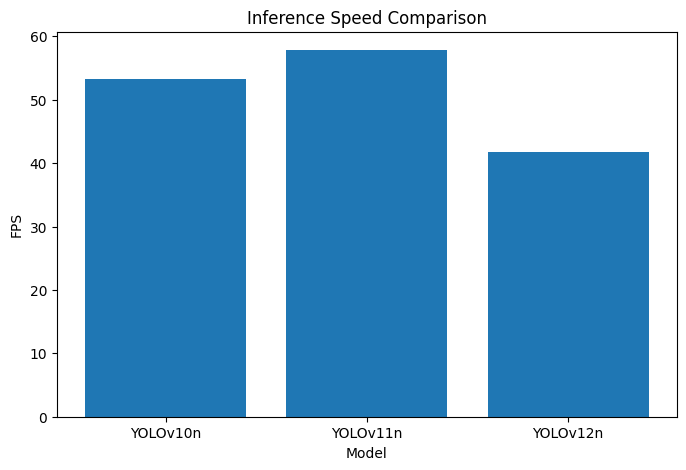

In [10]:
valid_df = df.dropna(subset=["FPS"])

plt.figure(figsize=(8, 5))
plt.bar(valid_df["Model"], valid_df["FPS"])
plt.xlabel("Model")
plt.ylabel("FPS")
plt.title("Inference Speed Comparison")
plt.show()

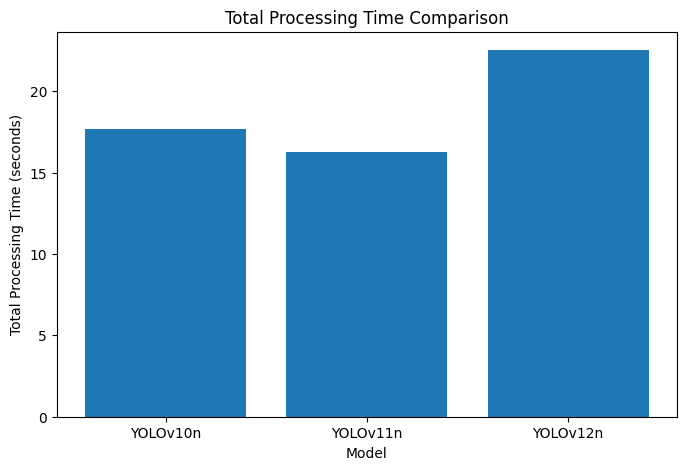

In [11]:
valid_df = df.dropna(subset=["Total Processing Time (s)"])

plt.figure(figsize=(8, 5))
plt.bar(valid_df["Model"], valid_df["Total Processing Time (s)"])
plt.xlabel("Model")
plt.ylabel("Total Processing Time (seconds)")
plt.title("Total Processing Time Comparison")
plt.show()

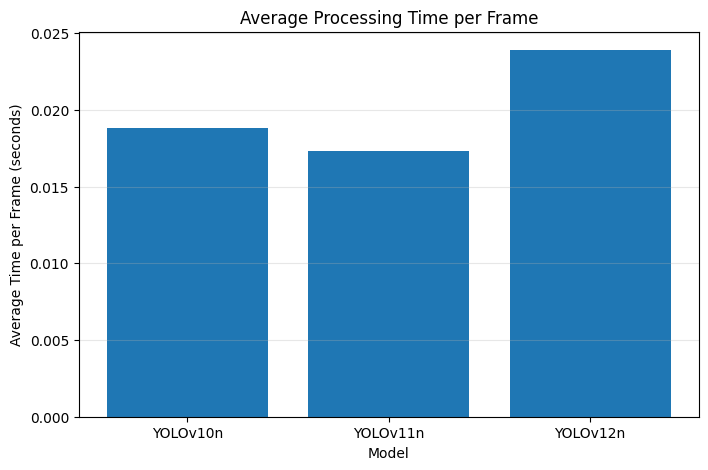

In [17]:
valid_df = df.dropna(subset=["Average Time per Frame (s)"])

plt.figure(figsize=(8, 5))
plt.bar(valid_df["Model"], valid_df["Average Time per Frame (s)"])
plt.xlabel("Model")
plt.ylabel("Average Time per Frame (seconds)")
plt.title("Average Processing Time per Frame")
plt.grid(axis="y", alpha=0.3)
plt.show()

Apply tracking on th video

In [12]:
video_path = "/content/Test.mp4"

model = YOLO("yolo11n.pt")

In [13]:
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

output_path = "/content/tracked_video.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0
start_total = time.time()

while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.25,
        verbose=False
    )

    annotated_frame = results[0].plot()
    out.write(annotated_frame)

    frame_count += 1

end_total = time.time()

cap.release()
out.release()

total_time = end_total - start_total
processing_fps = frame_count / total_time

print("Tracking finished.")
print("Frames processed:", frame_count)
print("Total time:", round(total_time, 2), "seconds")
print("Processing FPS:", round(processing_fps, 2))
print("Saved video:", output_path)

Tracking finished.
Frames processed: 942
Total time: 30.68 seconds
Processing FPS: 30.71
Saved video: /content/tracked_video.mp4


In [16]:
from google.colab import files
files.download("/content/tracked_video.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
def arr_to_pil(bgr):
    return Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

def show_uploaded_video(video_path):
    if not video_path:
        return None, "Waiting for video upload..."
    return video_path, f"✅ Video uploaded: {video_path.split('/')[-1]}"

def fmt_num(v):
    if isinstance(v, (int, float)):
        if abs(v) >= 1000:
            return f"{v:,.0f}"
        if abs(v) >= 100:
            return f"{v:.1f}"
        if abs(v) >= 10:
            return f"{v:.2f}"
        return f"{v:.4f}".rstrip("0").rstrip(".")
    return str(v)

def make_dashboard_html(df):
    if df is None or len(df) == 0:
        return """
        <div class="metric-grid">
            <div class="metric-card">
                <div class="metric-title">Best Model</div>
                <div class="metric-value">-</div>
                <div class="metric-sub">Waiting for run</div>
            </div>
            <div class="metric-card">
                <div class="metric-title">Best FPS</div>
                <div class="metric-value">-</div>
                <div class="metric-sub">Frames / second</div>
            </div>
            <div class="metric-card">
                <div class="metric-title">Lowest Time</div>
                <div class="metric-value">-</div>
                <div class="metric-sub">Processing time</div>
            </div>
            <div class="metric-card">
                <div class="metric-title">Avg ms / Frame</div>
                <div class="metric-value">-</div>
                <div class="metric-sub">Lower is better</div>
            </div>
        </div>
        """

    best = df.iloc[0]

    return f"""
    <div class="metric-grid">
        <div class="metric-card">
            <div class="metric-title">Best Model</div>
            <div class="metric-value">{best["Model"]}</div>
            <div class="metric-sub">Highest FPS</div>
        </div>
        <div class="metric-card">
            <div class="metric-title">Best FPS</div>
            <div class="metric-value">{fmt_num(best["FPS"])}</div>
            <div class="metric-sub">Frames / second</div>
        </div>
        <div class="metric-card">
            <div class="metric-title">Total Time</div>
            <div class="metric-value">{fmt_num(best["Total Time (s)"])}s</div>
            <div class="metric-sub">Processing time</div>
        </div>
        <div class="metric-card">
            <div class="metric-title">Avg Frame Time</div>
            <div class="metric-value">{fmt_num(best["Avg ms/Frame"])}ms</div>
            <div class="metric-sub">Lower is better</div>
        </div>
    </div>
    """

def make_chart(df):
    metrics = [
        ("FPS", "FPS", True),
        ("Total Time (s)", "Total Time (s)", False),
        ("Avg ms/Frame", "Avg ms / Frame", False),
        ("Total Detections", "Total Detections", True),
        ("Unique IDs", "Unique Tracked IDs", True),
        ("Avg Confidence", "Average Confidence", True),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor("#060816")
    axes = axes.flatten()

    for ax, (col, title, high_is_best) in zip(axes, metrics):
        names = df["Model"].astype(str).values
        vals = df[col].astype(float).values

        best_value = max(vals) if high_is_best else min(vals)
        colors = ["#00E5C0" if v == best_value else "#334155" for v in vals]

        ax.set_facecolor("#111827")
        bars = ax.bar(names, vals, color=colors, edgecolor="#1F2937", linewidth=1.5, width=0.6)

        max_val = max(vals) if len(vals) > 0 else 1
        if max_val == 0:
            max_val = 1

        ax.set_ylim(0, max_val * 1.18)

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.04,
                fmt_num(val),
                ha="center",
                va="bottom",
                color="#F9FAFB",
                fontsize=11,
                fontweight="bold"
            )

        ax.set_title(title, color="#00E5C0", fontsize=13, fontweight="bold", pad=12)
        ax.tick_params(colors="#D1D5DB", labelsize=10)
        ax.grid(axis="y", color="#374151", linestyle="--", linewidth=0.7, alpha=0.55)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_color("#374151")

        plt.setp(ax.get_xticklabels(), rotation=0, ha="center", color="#D1D5DB")

    fig.suptitle(
        "YOLO Object Tracking Benchmark Results",
        color="#F9FAFB",
        fontsize=18,
        fontweight="bold",
        y=0.98
    )

    plt.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.98, hspace=0.38, wspace=0.22)
    return fig

def extract_frames(video_path):
    if not video_path:
        return []

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        return []

    frame_positions = [int(total * p) for p in [0.1, 0.35, 0.6, 0.85]]
    images = []

    for idx in frame_positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            images.append(arr_to_pil(frame))

    cap.release()
    return images

def run_benchmark(video_path, selected_models, conf, progress=gr.Progress()):
    if not video_path:
        return None, None, make_dashboard_html(None), None, None, "⚠️ Please upload a video first."

    if not selected_models:
        return None, None, make_dashboard_html(None), None, None, "⚠️ Please select at least one model."

    results_list = []
    output_videos = {}

    for i, model_name in enumerate(selected_models):
        weight = models[model_name]
        out_path = f"/tmp/{model_name}_tracked.mp4"

        model = YOLO(weight)
        cap = cv2.VideoCapture(video_path)

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        original_fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if original_fps <= 0:
            original_fps = 25

        writer = cv2.VideoWriter(
            out_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            original_fps,
            (width, height)
        )

        frame_count = 0
        total_time = 0
        total_detections = 0
        confidence_sum = 0
        confidence_count = 0
        unique_ids = set()

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            start = time.time()

            results = model.track(
                frame,
                persist=True,
                tracker="bytetrack.yaml",
                conf=conf,
                verbose=False
            )

            end = time.time()
            frame_time = end - start
            total_time += frame_time

            result = results[0]
            annotated_frame = result.plot()
            writer.write(annotated_frame)

            if result.boxes is not None:
                boxes = result.boxes
                total_detections += len(boxes)

                if boxes.conf is not None:
                    confs = boxes.conf.cpu().numpy()
                    confidence_sum += confs.sum()
                    confidence_count += len(confs)

                if boxes.id is not None:
                    ids = boxes.id.cpu().numpy().astype(int)
                    for track_id in ids:
                        unique_ids.add(track_id)

            frame_count += 1

            if total_frames > 0:
                progress(
                    (i + frame_count / total_frames) / len(selected_models),
                    desc=f"{model_name}: frame {frame_count}/{total_frames}"
                )

        cap.release()
        writer.release()

        avg_ms = (total_time / frame_count) * 1000 if frame_count > 0 else 0
        fps = frame_count / total_time if total_time > 0 else 0
        avg_conf = confidence_sum / confidence_count if confidence_count > 0 else 0

        results_list.append({
            "Model": model_name,
            "Frames": int(frame_count),
            "Total Time (s)": round(total_time, 3),
            "Avg ms/Frame": round(avg_ms, 2),
            "FPS": round(fps, 2),
            "Total Detections": int(total_detections),
            "Unique IDs": int(len(unique_ids)),
            "Avg Confidence": round(avg_conf, 4)
        })

        output_videos[model_name] = out_path

    df = pd.DataFrame(results_list)
    df = df.sort_values("FPS", ascending=False).reset_index(drop=True)

    display_df = df.copy()
    display_df["Avg Confidence"] = display_df["Avg Confidence"].map(lambda x: f"{x:.4f}")
    display_df["Total Time (s)"] = display_df["Total Time (s)"].map(lambda x: f"{x:.3f}")
    display_df["Avg ms/Frame"] = display_df["Avg ms/Frame"].map(lambda x: f"{x:.2f}")
    display_df["FPS"] = display_df["FPS"].map(lambda x: f"{x:.2f}")

    chart = make_chart(df)
    dashboard = make_dashboard_html(df)

    best_model = df.iloc[0]["Model"]
    best_video = output_videos[best_model]

    csv_path = "/tmp/yolo_tracking_benchmark_results.csv"
    df.to_csv(csv_path, index=False)

    status = f"✅ Benchmark completed successfully. Best model: {best_model}"

    return display_df, chart, dashboard, best_video, csv_path, status

def clear_all():
    return (
        None,
        None,
        list(models.keys()),
        0.25,
        make_dashboard_html(None),
        None,
        None,
        None,
        None,
        None,
        "Waiting for video upload..."
    )

CSS = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&family=JetBrains+Mono:wght@400;600;700&display=swap');

:root {
    --bg: #060816;
    --panel: rgba(13, 19, 35, 0.92);
    --border: #273449;
    --accent: #00E5C0;
    --accent2: #7C5CFF;
    --accent3: #22D3EE;
    --text: #F8FAFC;
    --muted: #94A3B8;
}

html, body {
    margin: 0 !important;
    padding: 0 !important;
    background: var(--bg) !important;
    overflow-x: hidden !important;
}

body, .gradio-container {
    background:
        radial-gradient(circle at 10% 10%, rgba(0,229,192,0.10), transparent 22%),
        radial-gradient(circle at 90% 12%, rgba(124,92,255,0.12), transparent 24%),
        radial-gradient(circle at 50% 100%, rgba(34,211,238,0.08), transparent 25%),
        linear-gradient(180deg, #050816 0%, #081124 100%) !important;
    color: var(--text) !important;
    font-family: 'Inter', sans-serif !important;
}

.gradio-container {
    width: 100vw !important;
    max-width: 100vw !important;
    padding: 18px 24px 30px 24px !important;
    margin: 0 !important;
}

footer { visibility: hidden !important; }

.gr-group, .gr-box, .gradio-group {
    background: var(--panel) !important;
    border: 1px solid var(--border) !important;
    border-radius: 22px !important;
    box-shadow: 0 18px 40px rgba(0,0,0,0.25) !important;
}

.cv-header {
    position: relative;
    overflow: hidden;
    width: 100%;
    background:
        linear-gradient(135deg, rgba(8,16,36,0.94), rgba(15,23,42,0.96)),
        linear-gradient(90deg, rgba(0,229,192,0.12), rgba(124,92,255,0.12));
    border: 1px solid var(--border);
    border-radius: 28px;
    padding: 42px 48px;
    margin-bottom: 20px;
    box-shadow: 0 24px 60px rgba(0,0,0,0.32);
}

.cv-header::before {
    content: "";
    position: absolute;
    top: -80px;
    right: -70px;
    width: 260px;
    height: 260px;
    border-radius: 50%;
    background: radial-gradient(circle, rgba(0,229,192,0.28), transparent 70%);
    filter: blur(6px);
}

.cv-header::after {
    content: "";
    position: absolute;
    bottom: -90px;
    left: -80px;
    width: 260px;
    height: 260px;
    border-radius: 50%;
    background: radial-gradient(circle, rgba(124,92,255,0.20), transparent 72%);
    filter: blur(8px);
}

.cv-tag {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    background: rgba(0,229,192,0.10);
    border: 1px solid rgba(0,229,192,0.30);
    color: var(--accent);
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    letter-spacing: 0.14em;
    text-transform: uppercase;
    padding: 8px 14px;
    border-radius: 999px;
    margin-bottom: 18px;
}

.cv-header h1 {
    margin: 0 0 12px 0;
    font-size: 50px;
    line-height: 1.04;
    letter-spacing: -0.04em;
    font-weight: 800;
}

.cv-gradient {
    background: linear-gradient(90deg, #FFFFFF 0%, #00E5C0 45%, #7C5CFF 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.cv-header p {
    margin: 0;
    max-width: 950px;
    color: var(--muted);
    font-size: 16px;
    line-height: 1.7;
}

.cv-author {
    margin-top: 24px;
    display: inline-flex;
    align-items: center;
    gap: 14px;
    background: rgba(18,26,45,0.86);
    border: 1px solid var(--border);
    border-left: 4px solid var(--accent);
    border-radius: 18px;
    padding: 14px 18px;
}

.cv-avatar {
    width: 48px;
    height: 48px;
    border-radius: 50%;
    background: linear-gradient(135deg, var(--accent), var(--accent2));
    display: flex;
    justify-content: center;
    align-items: center;
    color: #07111F;
    font-weight: 800;
    font-size: 15px;
}

.cv-name {
    color: var(--text);
    font-size: 16px;
    font-weight: 800;
}

.cv-id {
    color: var(--muted);
    font-family: 'JetBrains Mono', monospace;
    font-size: 12px;
    margin-top: 2px;
}

.panel-title {
    color: var(--accent);
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: 0.14em;
    margin-bottom: 8px;
}

label {
    color: var(--accent) !important;
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 11px !important;
    letter-spacing: 0.10em !important;
    text-transform: uppercase !important;
}

input[type=range] { accent-color: var(--accent); }

button, .gr-button {
    border-radius: 18px !important;
    font-weight: 800 !important;
    transition: all 0.25s ease !important;
    box-shadow: 0 10px 24px rgba(0,0,0,0.18) !important;
}

/* upload file component as button */
#video-upload {
    border: 2px dashed rgba(0,229,192,0.35) !important;
    border-radius: 20px !important;
    padding: 18px !important;
    background: linear-gradient(180deg, rgba(16,23,42,0.92), rgba(11,16,32,0.92)) !important;
    box-shadow: 0 14px 28px rgba(0,0,0,0.22) !important;
}

#video-upload button {
    width: 100% !important;
    min-height: 64px !important;
    border: none !important;
    border-radius: 18px !important;
    background: linear-gradient(135deg, #00E5C0, #22D3EE, #7C5CFF) !important;
    color: #07111F !important;
    font-size: 17px !important;
    font-weight: 800 !important;
    letter-spacing: 0.02em !important;
    box-shadow: 0 18px 38px rgba(0,229,192,0.24) !important;
}

#video-upload button:hover {
    transform: translateY(-2px) scale(1.01) !important;
    filter: brightness(1.04) !important;
}

#run-btn {
    width: 100% !important;
    min-height: 58px !important;
    background: linear-gradient(135deg, var(--accent), #05C9AE) !important;
    color: #07111F !important;
    border: none !important;
    font-size: 17px !important;
    margin-top: 10px !important;
    box-shadow: 0 16px 34px rgba(0,229,192,0.24) !important;
}

#run-btn:hover {
    transform: translateY(-2px) scale(1.01) !important;
    filter: brightness(1.04) !important;
    box-shadow: 0 18px 42px rgba(0,229,192,0.28) !important;
}

#clear-btn {
    width: 100% !important;
    min-height: 54px !important;
    background: linear-gradient(135deg, #1E293B, #111827) !important;
    color: var(--text) !important;
    border: 1px solid var(--border) !important;
    font-size: 15px !important;
    margin-top: 10px !important;
}

#clear-btn:hover {
    transform: translateY(-2px) !important;
    border-color: var(--accent2) !important;
    box-shadow: 0 14px 32px rgba(124,92,255,0.18) !important;
}

.metric-grid {
    display: grid;
    grid-template-columns: repeat(4, minmax(0, 1fr));
    gap: 16px;
    margin: 8px 0 18px 0;
    width: 100%;
}

.metric-card {
    background: linear-gradient(180deg, rgba(20,29,52,0.95), rgba(13,19,35,0.96));
    border: 1px solid var(--border);
    border-radius: 20px;
    padding: 20px;
    min-height: 116px;
    box-shadow: 0 18px 34px rgba(0,0,0,0.20);
}

.metric-title {
    color: var(--muted);
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    text-transform: uppercase;
    letter-spacing: 0.10em;
}

.metric-value {
    margin-top: 10px;
    color: var(--accent);
    font-weight: 800;
    font-size: 28px;
    line-height: 1.2;
}

.metric-sub {
    margin-top: 6px;
    color: var(--muted);
    font-size: 12px;
}

.gr-dataframe {
    overflow: hidden !important;
    border-radius: 18px !important;
}

.gr-dataframe table {
    background: #101827 !important;
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 13px !important;
}

.gr-dataframe th {
    background: #172234 !important;
    color: var(--accent) !important;
    font-size: 10px !important;
    letter-spacing: 0.10em !important;
    text-transform: uppercase !important;
    border-color: #253247 !important;
}

.gr-dataframe td {
    color: var(--text) !important;
    border-color: #223045 !important;
}

#status-box textarea {
    background: #0F172A !important;
    border: 1px solid var(--border) !important;
    color: var(--accent) !important;
    border-radius: 14px !important;
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 12px !important;
}

/* make chart area fully visible */
#chart-box {
    min-height: 860px !important;
}

#chart-box .wrap,
#chart-box .empty,
#chart-box .block {
    min-height: 860px !important;
}

.gr-checkboxgroup {
    gap: 10px !important;
}

.gr-checkboxgroup label {
    background: linear-gradient(180deg, rgba(20,29,52,0.96), rgba(14,20,36,0.96)) !important;
    border: 1px solid var(--border) !important;
    border-radius: 14px !important;
    padding: 12px 14px !important;
    min-height: 48px !important;
    display: flex !important;
    align-items: center !important;
    transition: all 0.22s ease !important;
    box-shadow: 0 8px 18px rgba(0,0,0,0.16) !important;
}

.gr-checkboxgroup label:hover {
    border-color: rgba(0,229,192,0.55) !important;
    transform: translateY(-1px) !important;
    box-shadow: 0 12px 24px rgba(0,229,192,0.10) !important;
}

.gr-checkboxgroup label:has(input:checked) {
    background: linear-gradient(135deg, rgba(0,229,192,0.16), rgba(124,92,255,0.16)) !important;
    border-color: var(--accent) !important;
    color: var(--text) !important;
    box-shadow: 0 14px 28px rgba(0,229,192,0.14) !important;
}

.gradio-container .gr-image,
.gradio-container .gr-video,
.gradio-container .gr-gallery,
.gradio-container .gr-plot {
    border-radius: 18px !important;
    overflow: hidden !important;
}

.gr-row {
    gap: 18px !important;
}

@media (max-width: 1200px) {
    .metric-grid {
        grid-template-columns: repeat(2, minmax(0, 1fr));
    }
    .cv-header h1 { font-size: 42px; }
}

@media (max-width: 768px) {
    .gradio-container { padding: 14px !important; }
    .metric-grid { grid-template-columns: 1fr; }
    .cv-header { padding: 28px 24px; }
    .cv-header h1 { font-size: 34px; }
}
"""

try:
    app_context = gr.Blocks(css=CSS, title="YOLO Tracking Benchmark", fill_width=True)
except TypeError:
    app_context = gr.Blocks(css=CSS, title="YOLO Tracking Benchmark")

with app_context as app:

    gr.HTML("""
    <div class="cv-header">
        <div class="cv-tag">● Computer Vision / Object Tracking Benchmark</div>
        <h1><span class="cv-gradient">YOLO Object Tracking</span> Speed Comparison</h1>
        <p>
            Apply ByteTrack object tracking on the same video using YOLOv10n, YOLOv11n, and YOLOv12n.
            The dashboard compares FPS, processing time, average frame time, detections, tracking IDs, and confidence.
        </p>
        <div class="cv-author">
            <div class="cv-avatar">SA</div>
            <div>
                <div class="cv-name">Seif Ahmed</div>
                <div class="cv-id">ID 202202307</div>
            </div>
        </div>
    </div>
    """)

    dashboard_html = gr.HTML(make_dashboard_html(None))

    with gr.Row(equal_height=True):

        with gr.Column(scale=4, min_width=420):
            gr.HTML('<div class="panel-title">01 — Upload Video</div>')
            video_upload = gr.File(
                label="Upload Video",
                file_types=["video"],
                type="filepath",
                elem_id="video-upload"
            )

            video_preview = gr.Video(label="Uploaded Video Preview", height=240)

            gr.HTML('<div class="panel-title" style="margin-top:16px;">02 — Select Models</div>')
            model_select = gr.CheckboxGroup(
                choices=list(models.keys()),
                value=list(models.keys()),
                label="Models"
            )

            gr.HTML('<div class="panel-title" style="margin-top:16px;">03 — Tracking Settings</div>')
            conf_slider = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.25,
                step=0.05,
                label="Confidence Threshold"
            )

            run_btn = gr.Button("▶ Run Tracking Benchmark", elem_id="run-btn")
            clear_btn = gr.Button("✦ Clear / Reset", elem_id="clear-btn")

            status_box = gr.Textbox(
                label="Status",
                value="Waiting for video upload...",
                interactive=False,
                elem_id="status-box"
            )

            csv_output = gr.File(label="Download CSV Results")

        with gr.Column(scale=8, min_width=650):
            gr.HTML('<div class="panel-title">04 — Speed and Tracking Results</div>')
            results_table = gr.Dataframe(
                headers=[
                    "Model",
                    "Frames",
                    "Total Time (s)",
                    "Avg ms/Frame",
                    "FPS",
                    "Total Detections",
                    "Unique IDs",
                    "Avg Confidence"
                ],
                label="Benchmark Table",
                interactive=False
            )

            gr.HTML('<div class="panel-title" style="margin-top:16px;">05 — Visual Comparison Charts</div>')
            chart_output = gr.Plot(label="Benchmark Charts", elem_id="chart-box")

    with gr.Row(equal_height=True):
        with gr.Column(scale=7):
            gr.HTML('<div class="panel-title">06 — Best Model Tracked Video</div>')
            video_output = gr.Video(label="Best Model Output", height=420)

        with gr.Column(scale=5):
            gr.HTML('<div class="panel-title">07 — Sample Tracked Frames</div>')
            frames_output = gr.Gallery(
                label="Preview Frames",
                columns=2,
                height=420,
                object_fit="cover"
            )

    video_upload.change(
        fn=show_uploaded_video,
        inputs=[video_upload],
        outputs=[video_preview, status_box]
    )

    run_btn.click(
        fn=run_benchmark,
        inputs=[video_upload, model_select, conf_slider],
        outputs=[
            results_table,
            chart_output,
            dashboard_html,
            video_output,
            csv_output,
            status_box
        ]
    )

    video_output.change(
        fn=extract_frames,
        inputs=[video_output],
        outputs=[frames_output]
    )

    clear_btn.click(
        fn=clear_all,
        inputs=[],
        outputs=[
            video_upload,
            video_preview,
            model_select,
            conf_slider,
            dashboard_html,
            results_table,
            chart_output,
            video_output,
            frames_output,
            csv_output,
            status_box
        ]
    )

app.launch(share=True, debug=False)

/tmp/ipykernel_2985/1359748864.py:689: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  app_context = gr.Blocks(css=CSS, title="YOLO Tracking Benchmark", fill_width=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a770ede35318af0084.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
